# PCLab#4

This notebook presents the analysis conducted for the fourth lab (PC Lab #4) of the Finance with Big Data course. In this project, we assume the role of a quantitative analyst at a hedge fund, tasked with predicting stock returns using machine learning techniques. The objective is to leverage high-frequency financial data—specifically stock prices and trading volumes—to build predictive models for returns over multiple horizons.

The analysis involves data preprocessing and visualization, followed by the implementation and comparison of different models, including linear approaches (OLS and Ridge regression) and more advanced machine learning methods such as neural networks or tree-based models. Model performance is evaluated using out-of-sample metrics, and the predictions are ultimately used to construct an AI-driven trading strategy. The performance of this strategy is then assessed against random portfolios and under realistic conditions that include transaction costs, in order to determine the practical value of machine learning in asset pricing and portfolio management.

In [ ]:
import pandas as pd
import numpy as np
import requests
import bs4
import yfinance as yf
from datetime import datetime
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss, accuracy_score
from itertools import product
import statsmodels.api as sm
import plotly.express as px
import tensorflow as tf
from IPython.display import display
import random

from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from xgboost import XGBRegressor
import xgboost as xgb


## Given Data

In [ ]:
price = pd.read_csv('./data/Data_PCLab4_Stock_Price.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
volume = pd.read_csv('./data/Data_PCLab4_Stock_Volume.csv')

In [ ]:
price.head()

,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,60.198570,75.510002,30.120001,12.13,175.929993,180.550003,28.250000,313.644379,1295.500000
1,2012-01-13,59.972858,74.599998,30.070000,12.35,178.419998,179.160004,22.790001,311.328064,1289.089966
2,2012-01-17,60.671429,75.239998,30.250000,12.25,181.660004,180.000000,26.600000,313.116364,1293.670044
3,2012-01-18,61.301430,75.059998,30.330000,12.73,189.440002,181.070007,26.809999,315.273285,1308.040039
4,2012-01-19,61.107143,75.559998,30.420000,12.80,194.449997,180.520004,26.760000,318.590851,1314.500000


In [ ]:
volume.head()

,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,53146800,3934500,26511100,17891100,5385800,6881000,729300,3764400,4019890000
1,2012-01-13,56505400,4641100,22096800,16621800,4753500,5279200,5500400,4631800,3692370000
2,2012-01-17,60724300,3700100,23500200,15480800,5644500,6003400,4651600,3832800,4010490000
3,2012-01-18,69197800,4189500,22015000,18387600,7473500,4600600,1260200,5544000,4096160000
4,2012-01-19,65434600,5397300,25524000,14022900,7096000,8567200,1246300,12657800,4465890000


## Scraped Data

In [ ]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
resp.raise_for_status()

soup = bs4.BeautifulSoup(resp.text, "lxml")

table = soup.select_one("table#constituents")
rows = table.select("tbody tr")[1:]

tickers = []
for r in rows:
    t = r.select_one("td").get_text(strip=True)
    tickers.append(t)

tickers = [t.replace(".", "-") for t in tickers]

start = datetime(2012, 1, 12)
end   = datetime(2020, 8, 12)

data = yf.download(tickers, start=start, end=end, group_by="ticker", auto_adjust=False)

[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
13 Failed downloads:
ERROR:yfinance:['KVUE', 'EXE', 'GEHC', 'ABNB', 'GEV', 'VLTO', 'DASH', 'COIN', 'APP', 'HOOD', 'CEG', 'PLTR', 'SOLV']: YFPricesMissingError('possibly delisted; no price data found  (1d 2012-01-12 00:00:00 -> 2020-08-12 00:00:00) (Yahoo error = "Data doesn\'t exist for startDate = 1326344400, endDate = 1597204800")')


In [ ]:
df_web = (data.stack(level=0).reset_index().set_index("Date"))

df_web.columns.name = None

df_web = df_web.reset_index()
df_web.head()

/tmp/ipython-input-1048013887.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_web = (data.stack(level=0).reset_index().set_index("Date"))


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2012-01-12,A,27.997139,28.311874,27.439199,28.268955,25.115629,3973396.0
1,2012-01-12,AAPL,15.081429,15.103571,14.955357,15.049643,12.650176,212587200.0
2,2012-01-12,ABT,26.700871,26.811224,26.446575,26.465769,20.267300,15528762.0
3,2012-01-12,ACGL,12.310000,12.403333,12.310000,12.403333,11.794311,1439700.0
4,2012-01-12,ACN,53.189999,54.060001,53.000000,53.939999,41.967865,5096400.0


## Merged Data

In this section, we construct a **unified dataset** that combines, for each trading date, information on both **individual stocks** and the **S&P500 index**.
The S&P500 daily prices and volumes are retrieved from the `Data_PCLab4_Stock_Price` and `Data_PCLab4_Stock_Volume` datasets.

In [ ]:
df_web = df_web[["Date", "Ticker", "Adj Close", "Volume"]].copy()

# Build SP500 rows from the given price/volume tables
sp500_rows = (
    price[["Date", "sp500"]]
      .merge(volume[["Date", "sp500"]], on="Date", suffixes=("_price", "_volume"))
      .rename(columns={"sp500_price": "Adj Close", "sp500_volume": "Volume"})
)

sp500_rows["Ticker"] = "SP500"
sp500_rows = sp500_rows[["Date", "Ticker", "Adj Close", "Volume"]]


sp500_rows["Date"] = pd.to_datetime(sp500_rows["Date"])
df_web["Date"]     = pd.to_datetime(df_web["Date"])

# Concatenating the data from Yahoo and the sp500 rows
df = pd.concat([df_web, sp500_rows], ignore_index=True)
df = df.sort_values(["Date", "Ticker"]).reset_index(drop=True)

df.head()

,Date,Ticker,Adj Close,Volume
0,2012-01-12,A,25.115629,3973396.0
1,2012-01-12,AAPL,12.650176,212587200.0
2,2012-01-12,ABT,20.267300,15528762.0
3,2012-01-12,ACGL,11.794311,1439700.0
4,2012-01-12,ACN,41.967865,5096400.0


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

## Creation of Volumes and Prices DataFrames

To create the `volumes` and `prices` dataframes, df is reshaped into a wide format using pivot, where:
- The index is Date
- The columns are stock tickers
- The values are daily trading volumes for each stock or the daily prices, depending on the DataFrame we are creating

Since some tickers contained **many missing observations**, often due to **changes in the S&P 500** composition (from where we gathered our tickers), we remove all columns with incomplete values, keeping only stocks with a complete price history.

In [ ]:
#volumes
volumes = df.pivot(index="Date", columns="Ticker", values="Volume").reset_index()
missing_cols = volumes.columns[volumes.isna().any()]
print(missing_cols)
volumes = volumes.dropna(axis=1, how="any")


Index(['ABBV', 'ALLE', 'AMCR', 'ANET', 'CARR', 'CDW', 'CFG', 'CRWD', 'CTVA',
       'DAY', 'DDOG', 'DELL', 'DOW', 'EPAM', 'FANG', 'FOX', 'FOXA', 'FTV',
       'GDDY', 'HLT', 'HPE', 'HWM', 'INVH', 'IQV', 'IR', 'KEYS', 'KHC', 'LW',
       'META', 'MRNA', 'NCLH', 'NOW', 'NWS', 'NWSA', 'OTIS', 'PANW', 'PAYC',
       'PSX', 'PYPL', 'SYF', 'TTD', 'UBER', 'VICI', 'VST', 'WDAY', 'XYZ',
       'ZTS'],
      dtype='object', name='Ticker')


In [ ]:
#prices
prices = df.pivot(index="Date", columns="Ticker", values="Adj Close").reset_index()
missing_cols = prices.columns[prices.isna().any()]
print(missing_cols)
prices = prices.dropna(axis=1, how="any")

Index(['ABBV', 'ALLE', 'AMCR', 'ANET', 'CARR', 'CDW', 'CFG', 'CRWD', 'CTVA',
       'DAY', 'DDOG', 'DELL', 'DOW', 'EPAM', 'FANG', 'FOX', 'FOXA', 'FTV',
       'GDDY', 'HLT', 'HPE', 'HWM', 'INVH', 'IQV', 'IR', 'KEYS', 'KHC', 'LW',
       'META', 'MRNA', 'NCLH', 'NOW', 'NWS', 'NWSA', 'OTIS', 'PANW', 'PAYC',
       'PSX', 'PYPL', 'SYF', 'TTD', 'UBER', 'VICI', 'VST', 'WDAY', 'XYZ',
       'ZTS'],
      dtype='object', name='Ticker')


# **Task 1**: Basic Manipulation and Descriptive Statistics

## Describe the sample

In this section, we provide a preliminary overview of the dataset by examining the trading volumes of selected stocks and the S&P500 index.

We computed:

- The **average daily trading volume** for **Apple** (AAPL) which is approximately **232,813,949 shares**.
- The **maximum daily trading volume** recorded for the **S&P500** which equals to **9,044,690,000**.

Additionally, we identify the most actively traded securities in two ways:
1. By **average daily trading volume**: the most traded stock on average is **NVIDIA** (NVDA), with about 449,412,285 shares traded per day.
2. By **total trading volume** over the entire sample period: **NVIDIA** (NVDA) again ranks first, with a total traded volume of roughly 970,281,124,000 shares.

We **exclude the S&P500** index from these rankings because its **aggregated trading volume** is substantially **higher** than that of individual stocks, which would otherwise dominate the results and obscure meaningful comparisons among individual securities.

Finally, we visualize the **Top 10 most traded stocks** (always excluding the S&P500) to highlight the most liquid assets in the dataset.

In [ ]:
aapl_avg_volume = df.loc[df['Ticker']== 'AAPL','Volume'].mean()
print(f'The average volume for Apple stock is {aapl_avg_volume:,.3f}')

The average volume for Apple stock is 232,813,949.050


In [ ]:
max_trading_vol = df.loc[df['Ticker']== 'SP500','Volume'].max()
print(f'The maximum trading volume for the SP500 stock is {max_trading_vol:,.3f}')

The maximum trading volume for the SP500 stock is 9,044,690,000.000


In [ ]:
# Most traded security by average daily trading volume excluding S&P500
avg_volumes = df_web.groupby("Ticker")["Volume"].mean().sort_values(ascending=False)
most_traded_avg = avg_volumes.idxmax()
most_traded_value = avg_volumes.max()

print(f"The most traded stock on average is {most_traded_avg} with an average daily volume of {most_traded_value:,.3f}")

The most traded stock on average is NVDA with an average daily volume of 449,412,285.317


In [ ]:
# Most traded security by total trading volume across the whole period excluding S&P500
total_volumes = df_web.groupby("Ticker")["Volume"].sum().sort_values(ascending=False)
most_traded_total = total_volumes.idxmax()
most_traded_total_value = total_volumes.max()

print(f"The most traded stock overall is {most_traded_total} with a total volume of {most_traded_total_value:,.3f}")

The most traded stock overall is NVDA with a total volume of 970,281,124,000.000


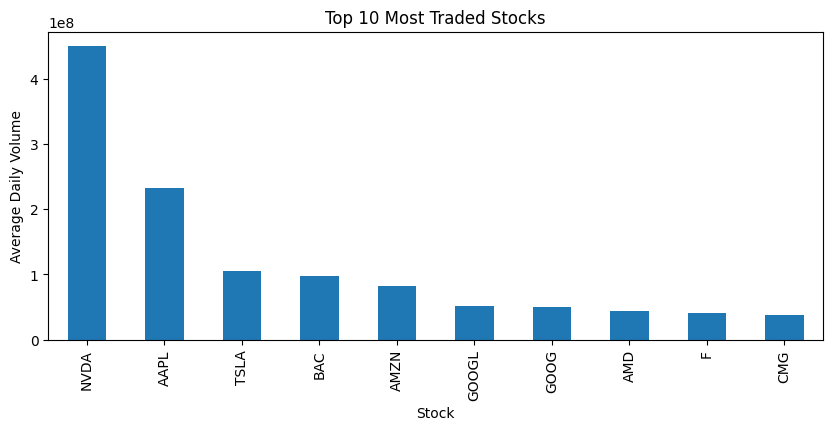

In [ ]:
plt.figure(figsize=(10, 4))
avg_volumes.head(10).plot(kind='bar', title='Top 10 Most Traded Stocks')
plt.xlabel('Stock')
plt.ylabel('Average Daily Volume')
plt.show()

These figures suggest that **NVIDIA** and **Apple** are among the **most liquid** and **actively traded** stocks in the S&P500. Their high trading volumes reflect strong investor interest and institutional activity, likely driven by their large market capitalization, tech-sector prominence and frequent news coverage.


## Plot the time series of volumes

In this section, we visualize the **trading volume** for the stocks in the dataset, both in **raw** and **normalized** form.

Analyzing trading volume is important because it reflects market liquidity and investor activity, which can provide insight into how actively each stock is traded over time.

Since our dataset contains roughly 500 stocks, we restrict the visualization to the **Top 10 stocks** by **average daily trading volume**. As before, exclude the S&P500 index, as its aggregated trading volume would dominate the chart and obscure meaningful comparisons among other securities.

To compare **relative changes** in trading activity across stocks of different sizes, we **normalize** each series by by its first available value, according to: $$ V_{t,i}^{norm} = \frac{V_{t,i}}{V_{0,i}} * 100 $$

This normalization sets the initial trading volume of each stock to 100, allowing us to interpret subsequent values as **percentage changes** relative to the starting level.

This approach allows us to understand how trading intensity evolves over time and **makes the dynamics comparable** across stocks with very different absolute volume scales.

In [ ]:
topN = (df[df["Ticker"] != "SP500"].groupby("Ticker")["Volume"].mean().nlargest(10).index) #top10 by average daily volume
volumes_top = volumes[topN]

In [ ]:
# plot raw volumes
fig_raw = go.Figure()

for ticker in topN:
    fig_raw.add_trace(
        go.Scatter(
            x=volumes["Date"],
            y=volumes[ticker],
            mode="lines",
            name=ticker,
            hovertemplate="Date=%{x}<br>Volume=%{y:.0f}<extra></extra>",))

fig_raw.update_layout(
    title="Stock Volumes — Raw",
    xaxis_title="Date",
    yaxis_title="Volume",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0),
    xaxis=dict(rangeslider=dict(visible=True)))

fig_raw.show()

The chart above shows the raw daily trading volumes of the ten most actively traded stocks.

From around 2016 onward, **NVIDIA** (NVDA) dominates market activity, with trading volumes often being several times higher than any other stock in the sample.

This surge coincides with NVIDIA's transformation from a niche graphics-chip maker into a core player in artificial intelligence and high-performance computing.

The pronounced spike in 2017 aligns with the company's launch of its revolutionary Volta GPU platform, which marked a turning point in the development of AI hardware and accelerated computing capabilities [NVIDIA, 2017](https://nvidianews.nvidia.com/news/nvidia-launches-revolutionary-volta-gpu-platform-fueling-next-era-of-ai-and-high-performance-computing)

In [ ]:
# Normalize
norm_volumes = (volumes_top - volumes_top.mean()) / volumes_top.std()

# Plot normalized volumes
fig_norm = go.Figure()

for ticker in norm_volumes.columns:
    fig_norm.add_trace(
        go.Scatter(
            x=volumes["Date"],
            y=norm_volumes[ticker],
            mode="lines",
            name=ticker,
            hovertemplate="Date=%{x}<br>"+f"{ticker}=%{{y:.1f}}<extra></extra>",))

fig_norm.update_layout(
    title="Top 10 Stocks by Total Volume — Normalized (Base = 100)",
    xaxis_title="Date",
    yaxis_title="Volume Index (Base = 100)",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0),
    xaxis=dict(rangeslider=dict(visible=True)))

fig_norm.show()

The figure above presents the **normalized trading volumes** for the ten most liquid stocks in the dataset, with each series indexed to 100 at its first available observation.

This normalization removes scale differences and allows for a direct comparison of relative changes in trading activity across firms over time.


## Correlation between change in prices (returns) and change in volumes

In this part, we study the relationship between daily stock returns and changes in trading volume.
For each ticker, we compute the correlation between the two series using daily percentage changes, and then summarize the results across all stocks.

In [ ]:
returns = prices.set_index("Date").pct_change()
volume_changes = volumes.set_index("Date").pct_change()

In [ ]:
returns, volume_changes = returns.align(volume_changes, join="inner")

In [ ]:
returns = returns.replace([np.inf, -np.inf], np.nan)
volume_changes = volume_changes.replace([np.inf, -np.inf], np.nan)

returns = returns.dropna()
volume_changes = volume_changes.dropna()

In [ ]:
corrs_normal = returns.corrwith(volume_changes, axis=0)
print("Top 10 tickers by correlation (normal returns):")
print(corrs_normal.sort_values(ascending=False).head(10))
print(" ")
print("Worse 10 tickers by correlation (normal returns):")
print(corrs_normal.sort_values(ascending=False).tail(10))

Top 10 tickers by correlation (normal returns):
Ticker
VRTX    0.591898
KDP     0.491767
BIIB    0.362057
STZ     0.343329
CF      0.210378
FSLR    0.201080
APA     0.196926
AMD     0.195866
TGT     0.183116
DECK    0.160444
dtype: float64
 
Worse 10 tickers by correlation (normal returns):
Ticker
JNJ    -0.271941
PTC    -0.275511
D      -0.288314
KR     -0.299776
IFF    -0.312018
BDX    -0.323002
EFX    -0.360639
MOH    -0.383059
FE     -0.392828
CTSH   -0.458040
dtype: float64


In [ ]:
corrs_topN = corrs_normal[topN]

fig = px.bar(
    x=corrs_topN.index,
    y=corrs_topN.values,
    labels={"x": "Stock", "y": "Correlation"},
    title="Correlation between stock returns and volume changes (Top 10 by average volume)",
)

fig.update_traces(marker_color='royalblue', opacity=0.8)
fig.update_layout(
    title_x=0.5,
    title_font=dict(size=20, color="#2c3e50"),
    font=dict(size=14, color="#2c3e50"),
    plot_bgcolor="#eaf0f6",
    paper_bgcolor="white",
    bargap=0.4,
)

fig.show()


The chart below above how strongly daily price returns move with daily trading volume changes for the ten most heavily traded stocks.
Most **correlations are near zero**, meaning price and volume fluctuations are **independent** from day to day.
A few names stand out: **AMD** shows a **modest positive correlation**, showing that price gains often coincide with higher volumes. On the contrary, **CMG** shows a **mild negative correlation**.

In [ ]:
# Top by average volume
tickers_to_plot = list(topN)

avg_annual_return = returns[tickers_to_plot].mean() * 252          # mean daily return -> annualized
avg_volume_change = volume_changes[tickers_to_plot].mean()         # mean volume pct-change

plot_df = pd.DataFrame({
    "Stock": tickers_to_plot,
    "Avg Annual Return": avg_annual_return.values,
    "Avg Volume Change": avg_volume_change.values
}).set_index("Stock")

plot_df = plot_df.sort_values(by="Avg Annual Return", ascending=False)

fig = px.bar(
    data_frame=plot_df,
    x=plot_df.index,
    y="Avg Annual Return",
    color="Avg Volume Change",
    title="Average Annual Return (colored by Average Volume Change)",
)

fig.update_xaxes(title_text="Stock")
fig.update_yaxes(title_text="Average Annual Return")
fig.update_layout(coloraxis_colorbar=dict(title="Average Volume Change"))
fig.show()

The chart above compares the **average annual returns** of the most actively traded stocks, with color indicating their **average daily volume change**. **TSLA** leads with the **highest annual return** and the **largest volume fluctuations**, reflecting both strong performance and trading activity. **NVDA** and **AMD** also show **robust returns** but **differ in trading intensity**, with AMD exhibiting more variable volumes. The remaining stocks (AMZN, AAPL, BAC, GOOG, GOOGL, CMG, F) display **progressively lower returns** and generally steadier volume patterns.

Note: GOOG and GOOGL both refer to the same holding, Alphabet, the main difference is that GOOG shares (Class C) have no voting rights, while GOOGL shares (Class A) do.

In [ ]:
median_corr_normal = corrs_normal.median()
mean_corr_normal = corrs_normal.mean()

print(f"Median per-ticker correlation: {median_corr_normal:.4f}")
print(f"Mean per-ticker correlation:   {mean_corr_normal:.4f}")

Median per-ticker correlation: -0.0657
Mean per-ticker correlation:   -0.0549
Pooled correlation:            -0.0246


Correlations are **slightly negative on average**. This suggests that, on average, **price increases** tend to be associated with **small decreases in trading volume**, and vice versa, although the effect is very weak.

One possible explanation is that when prices rise, fewer investors may feel the need to trade, either because they are holding onto gains or waiting for better entry points. While sudden price drops can trigger a temporary increase in activity as investors adjust or rebalance their positions.

# **Task 2**: Train and Test samples + Ridge regression

## Defining General Model

In this section, we define a general modeling function used to estimate both **Ordinary Least Squares (OLS)** and **Ridge regression** models for predicting future stock returns or price levels at different horizons
($\Delta t$=5,20,60 trading days).
This function represents the core modeling framework for our Task 2 analysis.

1. **Model Setup**

We aim to predict either:
- future stock prices $P_{i,t+T}$

- future returns $r_{i,t+T} = \frac{P_{i,t+Δt}}{P_{i,t+Δt-1}}-1$

using information available at time t: past prices, returns, and trading volumes.

Formally, the model can be written as $$y_{i,t+\Delta t} = f(X_{i,t})+ ϵ_{i,t+\Delta t}$$



2. **Model Specification - OLS and Ridge**

Both models assume a linear link between predictors and the target:
- OLS estimates the best linear fit by minimizing squared errors.
- Ridge adds a penalty (chosen by cross-validation) to shrink large coefficients, improving stability when predictors are noisy or correlated.

3. **Train/Test Split and Scaling**

For each stock, data are sorted chronologically.
The first 75% of observations are used for training, and the last 25% for testing.
Features are scaled using a MinMaxScaler fitted only on the training data to prevent leakage.
Scaling is especially important for Ridge since the penalty depends on feature magnitudes.

4. **Evaluation Metrics**

For return predictions, we follow Gu et al. (2020) and use the zero benchmark:
$$ R_{OOS} = 1 - \frac{\sum_{t \in T_{\text{test}}} r_t^2}{\sum_{t \in T_{\text{test}}} r_t ^2}
$$
This measures whether the model improves upon simply predicting 0.

For price forecasts, using the same benchmark would be misleading since prices are always positive and move slowly. The numerator (errors) would be small and the denominator large, giving artificially high $R_{OOS}$ values.

Because prices are highly correlated, since the price of tomorrow is highly dependent from the level of price today, we compare against a random walk benchmark, refined as:
$$
R^{OOS}_{\text{price}} = 1 -
\frac{\sum_{t \in T_{\text{test}}} (P_t - \hat{P}_t)^2}
     {\sum_{t \in T_{\text{test}}} (P_t - P_{t-1})^2}
$$

This version is much more informative: it tests whether our model can beat the simplest possible forecast, where the expected price tomorrow is just today's price.

We also compute sign accuracy as follows:
$$
\text{SignAcc} = \frac{1}{N} \sum_{t=1}^{N} \mathbf{1}\{ \operatorname{sign}(\hat{y}_t) = \operatorname{sign}(y_t) \}
$$

In [ ]:
d = df.sort_values(["Ticker", "Date"]).copy()
d = d[d["Ticker"] != "SP500"].reset_index(drop=True)

d["return"] = d.groupby("Ticker")["Adj Close"].pct_change()


In [ ]:
def model(d, T, pred="Price", model="ols", cols_X=None, include_market=False, extra_signals=None):
    if cols_X is None:
        cols_X = ["return", "Volume"]
    if extra_signals is None:
        extra_signals = []
    if include_market:
        cols_X = cols_X + ["mkt_return"]
    cols_X = cols_X + extra_signals

    dm = d.dropna(subset=cols_X + [f"y_{T}"]).copy()

    # 75/25 split per ticker (chronological)
    dm["row"] = dm.groupby("Ticker").cumcount()
    dm["n"]   = dm.groupby("Ticker")["row"].transform("max") + 1
    dm["cut"] = (0.75 * dm["n"]).astype(int)
    dm["is_train"] = dm["row"] < dm["cut"]

    Xtr = dm.loc[dm.is_train, cols_X].values
    ytr = dm.loc[dm.is_train, f"y_{T}"].values
    Xte = dm.loc[~dm.is_train, cols_X].values
    yte = dm.loc[~dm.is_train, f"y_{T}"].values
    Pte = dm.loc[~dm.is_train, "Adj Close"].values
    Ptr = dm.loc[dm.is_train, "Adj Close"].values

    # Scaling
    sc_final = MinMaxScaler()
    Xtr_sc = sc_final.fit_transform(Xtr)
    Xte_sc = sc_final.transform(Xte)

    if model == "ols":
        Xtr_df = pd.DataFrame(Xtr_sc, columns=cols_X)
        Xte_df = pd.DataFrame(Xte_sc, columns=cols_X)
        Xtr_design = sm.add_constant(Xtr_df, has_constant='add')
        Xte_design = sm.add_constant(Xte_df, has_constant='add')
        mdl = sm.OLS(ytr, Xtr_design).fit()
        yhat_tr = mdl.predict(Xtr_design).to_numpy()
        yhat_te = mdl.predict(Xte_design).to_numpy()
    elif model == "ridge":
        # CV for lambda
        tscv = TimeSeriesSplit(n_splits=5, gap=T)
        best_l, best = None, np.inf
        for l in np.logspace(-4, 6, 50):
            mses = []
            for tr_idx, va_idx in tscv.split(Xtr):
                sc_fold = MinMaxScaler()
                X_tr_f = sc_fold.fit_transform(Xtr[tr_idx])
                X_va_f = sc_fold.transform(Xtr[va_idx])
                m = Ridge(alpha=l).fit(X_tr_f, ytr[tr_idx])
                p = m.predict(X_va_f)
                mses.append(mean_squared_error(ytr[va_idx], p))
            avg_mse = float(np.mean(mses))
            if avg_mse < best:
                best, best_l = avg_mse, l
        print(f"[Time Horizon={T}] Selected lambda (5-fold TS CV): {best_l:g}")
        mdl = Ridge(alpha=best_l).fit(Xtr_sc, ytr)
        yhat_tr = mdl.predict(Xtr_sc)
        yhat_te = mdl.predict(Xte_sc)
    else:
        raise ValueError("Unsupported model type")

    # Metrics
    if pred.lower() == "price":
        # Roos vs Random Walk (baseline = P_t)
        sse_model = np.sum((yte - yhat_te) ** 2)
        sse_naive = np.sum((yte - Pte) ** 2)
        R_oos = np.nan if sse_naive == 0 else 1.0 - sse_model / sse_naive

        # sign accuracy
        dy_true = yte - Pte
        dy_pred = yhat_te - Pte
        sign_acc = float(np.mean(np.sign(dy_true) == np.sign(dy_pred)))

    else:  # pred == "Return"
      denom = float(np.sum(yte ** 2))
      R_oos = 1 - np.sum((yte - yhat_te) ** 2) / denom if denom > 0 else np.nan
      sign_acc = float(np.mean(np.sign(yte) == np.sign(yhat_te)))

    print(f"\nR_OOS ({T}d, {model}, pred={pred}): {R_oos:.4f}")
    print(f"Sign accuracy ({T}d, {model}, pred={pred}): {sign_acc:.3f}")

    # Total data
    dm = dm.copy()
    dm["pred"] = np.nan
    dm.loc[dm.is_train, "pred"] = yhat_tr
    dm.loc[~dm.is_train, "pred"] = yhat_te

    out = dm.loc[:, ["Date","Ticker","Adj Close","Volume","return",f"y_{T}","is_train","pred"]].copy()
    return R_oos, sign_acc, out, mdl, sc_final

## Predicting Stock Prices - short (5 days) horizon - OLS

In this first test, we predict **stock prices five days ahea**d using a simple **OLS regression** with current prices and trading volumes as predictors.
The results show an out-of-sample $R_{OOS} = -0.0021$ and a sign accuracy of 55.6%.

The negative $R_{OOS}$ indicates that the model performs slightly worse than a random walk, meaning it does not provide meaningful predictive power.
This shows that short-term price changes are largely random and dominated by noise.

In [ ]:
cols_X =["Adj Close", "Volume"]
d["y_5"] = d.groupby("Ticker")["Adj Close"].shift(-5)
R_oos1,sign1,out1, model1, scaled_var1, = model(d, 5,pred = 'Price', model="ols", cols_X =cols_X, include_market=False, extra_signals=None)



R_OOS (5d, ols, pred=Price): -0.0021
Sign accuracy (5d, ols, pred=Price): 0.556


In [ ]:
apple = out1[out1['Ticker'] == 'AAPL'].copy().sort_values('Date')

sc_plot = MinMaxScaler()
apple[['Actual_scaled', 'Pred_scaled']] = sc_plot.fit_transform(apple[['y_5', 'pred']] )

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=apple['Date'], y=apple['Actual_scaled'],
    mode='lines', name='Actual Price (t+5, scaled)'))

fig.add_trace(go.Scatter(
    x=apple['Date'], y=apple['Pred_scaled'],
    mode='lines', name='Predicted Price (t+5, scaled)'))

fig.update_layout(
    title='Apple — Price Original vs. Predicted (5-day OLS)',
    xaxis_title='Date',
    yaxis_title='Scaled Price (0–1)',
    legend=dict(x=0, y=1.1, orientation='h'),
    template='plotly_white',
    hovermode='x unified')

fig.show()


The graph shows that the predicted series **almost perfectly follows the actual price path**, with the two lines practically overlapping across the entire period.

This visual appearence may seem to suggest a strong predictive accuracy, but it is mostly an illusion. The reason for this lies in the model's structure: since it uses the current price as one of the predictors, and stock prices are **highly autocorrelated**, the regression learns to reproduce the existing trend rather than uncover any predictive pattern.

In other words, the OLS model is not truly forecasting where prices will go next but it is simply **shifting the existing trajectory** a few days forward. This is why the visual match is strong, despite the out-of-sample performance remining weak.

## Predicting Stock Returns - short (5 days) horizon - OLS

When predicting 5-day returns (instead of prices) with OLS, results remain similar.
The model achieves an out-of-sample $R_{OOS}
 =-0.0007$ and a sign accuracy of 53.0%.

These results indicate **no meaningful predictive power**, confirming that short-term returns behave almost randomly and are very hard to forecast using basic price and volume information.

In [ ]:
cols_X =["return", "Volume"]
d["y_5"] = d.groupby("Ticker")["return"].shift(-5)
R_oos2,sign2,out2, model2, scaled_var2= model(d, 5, pred = 'Return', model="ols", cols_X =cols_X, include_market=False, extra_signals=None)


R_OOS (5d, ols, pred=Return): -0.0007
Sign accuracy (5d, ols, pred=Return): 0.530


In [ ]:
apple = out2[out2['Ticker'] == 'AAPL'].copy().sort_values('Date')

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=apple['Date'], y=apple['y_5'],
    mode='lines', name='Actual Return (t+5, scaled)'))

fig.add_trace(go.Scatter(
    x=apple['Date'], y=apple['pred'],
    mode='lines', name='Predicted Return (t+5, scaled)'))

fig.update_layout(
    title='Apple — Return Original vs. Predicted (5-day OLS)',
    xaxis_title='Date',
    yaxis_title='Return',
    legend=dict(x=0, y=1.1, orientation='h'),
    template='plotly_white',
    hovermode='x unified')

fig.show()


In this graph, the predicted 5-day returns remain nearly **flat around zero**, while the actual returns fluctuate sharply and unpredictably. This reveals the model's inability to capture meaningful patterns in short-term returns. Unlike prices, returns lack persistence or trend, leaving the OLS model with no stable structure for its predictions. Since returns, as shown in the graph above, oscilliate around zero the predicted ones tend instead to remain much closer to this "common level" (i.e. the mean which is ≈ 0)

## Predicting Stock Prices - short (5 days) horizon - RIDGE with CV

We repeat the 5-day ahead price prediction using a Ridge regression. To identify the most effective shrinking parameter, we also performed a **5-fold cross validation**.

However, this approach yields similar outcomes with an out-of-sample $R_{OOS}=-0.0021$ and a sign accuracy of 55.6%, identical to the OLS baseline.
The penalty has no meaningful effect, suggesting overfitting is not the main issue, the predictive signal simply isn't there.



In [ ]:
cols_X =["Adj Close", "Volume"]
d["y_5"] = d.groupby("Ticker")["Adj Close"].shift(-5)
R_oos3,sign3,out3, model3, scaled_var3= model(d, 5,pred = 'Price', model="ridge", cols_X =cols_X, include_market=False, extra_signals=None)

[Time Horizon=5] Selected lambda (5-fold TS CV): 0.0001

R_OOS (5d, ridge, pred=Price): -0.0021
Sign accuracy (5d, ridge, pred=Price): 0.556


In [ ]:
apple = out3[out3['Ticker'] == 'AAPL'].copy().sort_values('Date')

sc_plot = MinMaxScaler()
apple[['Actual_scaled', 'Pred_scaled']] = sc_plot.fit_transform(apple[['y_5', 'pred']] )

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=apple['Date'], y=apple['Actual_scaled'],
    mode='lines', name='Actual Price (t+5, scaled)'))

fig.add_trace(go.Scatter(
    x=apple['Date'], y=apple['Pred_scaled'],
    mode='lines', name='Predicted Price (t+5, scaled)'))

fig.update_layout(
    title='Apple — Price Original vs. Predicted (5-day Ridge)',
    xaxis_title='Date',
    yaxis_title='Scaled Price (0–1)',
    legend=dict(x=0, y=1.1, orientation='h'),
    template='plotly_white',
    hovermode='x unified')

fig.show()


Compared to the previous OLS model, the Ridge regression produces an almost identical visual outcome. The predicted prices again overlap almost perfectly with the actual ones.

## Predicting Stock Returns - short (5 days) horizon - RIDGE with CV

Using a Ridge regression to predict 5-day ahead returns, results do not change much from the previous ones, always empirically confirming that returns are unpredictable using simple price and volume features.

In [ ]:
cols_X =["return", "Volume"]
d["y_5"] = d.groupby("Ticker")["return"].shift(-5)
R_oos4,sign4,out4, model4, scaled_var4= model(d, 5, pred = 'Return',model="ridge", cols_X =cols_X, include_market=False, extra_signals=None)

[Time Horizon=5] Selected lambda (5-fold TS CV): 12.6486

R_OOS (5d, ridge, pred=Return): -0.0006
Sign accuracy (5d, ridge, pred=Return): 0.530


In [ ]:
apple = out4[out4['Ticker'] == 'AAPL'].copy().sort_values('Date')

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=apple['Date'], y=apple['y_5'],
    mode='lines', name='Actual Return (t+5, scaled)'))

fig.add_trace(go.Scatter(
    x=apple['Date'], y=apple['pred'],
    mode='lines', name='Predicted Return (t+5, scaled)'))

fig.update_layout(
    title='Apple — Return Original vs. Predicted (5-day Ridge)',
    xaxis_title='Date',
    yaxis_title='Return',
    legend=dict(x=0, y=1.1, orientation='h'),
    template='plotly_white',
    hovermode='x unified')

fig.show()


Compared to the OLS version, the Ridge regression produces an almost identical visual outcome: the predicted 5-day returns still stay close to zero while actual returns fluctuate violently.

## What about different time horizons?

Extending the prediction horizon to 20 and 60 days does not improve results.
Both OLS and Ridge models produce $R_{OOS}$ values close to zero, with sign accuracy steady around 53%.
Short-term randomness persists even over (slightly) longer windows.

In [ ]:
cols_X =["return", "Volume"]
d["y_20"] = d.groupby("Ticker")["return"].shift(-20)
R_oos5,sign5,out5, model5, scaled_var5= model(d, 20,pred = 'Return', model="ols", cols_X =cols_X, include_market=False, extra_signals=None)


R_OOS (20d, ols, pred=Return): 0.0003
Sign accuracy (20d, ols, pred=Return): 0.532


In [ ]:
cols_X =["return", "Volume"]
d["y_20"] = d.groupby("Ticker")["return"].shift(-20)
R_oos6,sign6,out6, model6, scaled_var6= model(d, 20,pred = 'Return', model="ridge", cols_X =cols_X, include_market=False, extra_signals=None)

[Time Horizon=20] Selected lambda (5-fold TS CV): 82.8643

R_OOS (20d, ridge, pred=Return): 0.0004
Sign accuracy (20d, ridge, pred=Return): 0.532


In [ ]:
cols_X =["return", "Volume"]
d["y_60"] = d.groupby("Ticker")["return"].shift(-60)
R_oos7,sign7,out7, model7, scaled_var7= model(d, 60,pred = 'Return', model="ols", cols_X =cols_X, include_market=False, extra_signals=None)


R_OOS (60d, ols, pred=Return): 0.0008
Sign accuracy (60d, ols, pred=Return): 0.531


In [ ]:
cols_X =["return", "Volume"]
d["y_60"] = d.groupby("Ticker")["return"].shift(-60)
R_oos8,sign8,out8, model8, scaled_var8= model(d, 60,pred = 'Return', model="ridge", cols_X =cols_X, include_market=False, extra_signals=None)

[Time Horizon=60] Selected lambda (5-fold TS CV): 7.90604

R_OOS (60d, ridge, pred=Return): 0.0008
Sign accuracy (60d, ridge, pred=Return): 0.531


## Improving the model ?

#### Including the market

We extend the 5-day ahead return prediction model by adding the **market return (S&P 500)** as an additional feature, to see whether market movements help explain short-term individual stock returns.

Including the market factor does not improve performance: $R_{OOS}$ values remain negative and sign accuracy stays around 53%.

This may be because at 5-day frequency, **market effects are too weak compared to idiosyncratic volatility**, which is why adding the market factor doesn't improve out-of-sample accuracy.

In [ ]:
mkt = df[df.Ticker=="SP500"].sort_values("Date").copy()
mkt = mkt.rename(columns={"Adj Close": "mkt_price"})
mkt["mkt_return"] = mkt["mkt_price"].pct_change()
d = d.merge(mkt[["Date","mkt_price", "mkt_return"]], on="Date", how="left")

In [ ]:
cols_X =["return", "Volume"]
d["y_5"] = d.groupby("Ticker")["return"].shift(-5)
R_oos9,sign9, out9, model9, scaled_var9= model(d, 5, pred = 'Return',model="ols", cols_X =cols_X, include_market=True, extra_signals=None)


R_OOS (5d, ols, pred=Return): -0.0043
Sign accuracy (5d, ols, pred=Return): 0.529


In [ ]:
cols_X =["return", "Volume"]
d["y_5"] = d.groupby("Ticker")["return"].shift(-5)
R_oos10,sign10,out10, model10, scaled_var10= model(d, 5,pred = 'Return', model="ridge", cols_X =cols_X, include_market=True, extra_signals=None)

[Time Horizon=5] Selected lambda (5-fold TS CV): 51.7947

R_OOS (5d, ridge, pred=Return): -0.0041
Sign accuracy (5d, ridge, pred=Return): 0.530


 #### Including more signals

To test whether richer information improves predictions, we extend the 5-day ahead return model by adding **momentum** and **lagged return** features.
These include 1-5 day lags of returns (`lag_1` to `lag_5`) and short and medium-term momentum measures (`mom_5`).
Even after adding momentum and lagged-return signals, predictive performance remains very weak.
Both OLS and Ridge still yield negative $R_{OOS}$ values and sign accuracy barely above random.

We believe that this is because, even with more features, the model is trying to explain something that's close to white noise. The additional signals don't contain stable, exploitable information at such short horizons.

In [ ]:
g = d.groupby("Ticker")

# Momentum
d["mom_5"]  = g["Adj Close"].transform(lambda s: s.pct_change(5))

# Lagged returnts
d["lag_1"] = d.groupby("Ticker")["return"].shift(1)
d["lag_2"] = d.groupby("Ticker")["return"].shift(2)
d["lag_3"] = d.groupby("Ticker")["return"].shift(3)
d["lag_4"] = d.groupby("Ticker")["return"].shift(4)
d["lag_5"] = d.groupby("Ticker")["return"].shift(5)

In [ ]:
extra_signals = ["lag_1","lag_2", "lag_3", "lag_4", "lag_5","mom_5"]

cols_X = ["return","Volume"]
d[f"y_5"] = d.groupby("Ticker")["return"].shift(-5)

R_oos11,sign11,out11, model11, scaled_var11 = model(d, T=5,pred = 'Return', model="ols", cols_X=cols_X, include_market=True, extra_signals=extra_signals)



R_OOS (5d, ols, pred=Return): -0.0054
Sign accuracy (5d, ols, pred=Return): 0.526


In [ ]:
extra_signals = ["lag_1","lag_2", "lag_3", "lag_4", "lag_5","mom_5","mom_20"]

cols_X = ["return","Volume"]
d[f"y_5"] = d.groupby("Ticker")["return"].shift(-5)

R_oos12,sign12,out12, model12, scaled_var12 = model(d, T=5,pred = 'Return', model="ridge", cols_X=cols_X, include_market=True, extra_signals=extra_signals)


[Time Horizon=5] Selected lambda (5-fold TS CV): 0.0281177

R_OOS (5d, ridge, pred=Return): -0.0052
Sign accuracy (5d, ridge, pred=Return): 0.527


### Including Fama-French

To enrich the feature set, we include the **Fama-French 5 Factors**: Market (MKT-RF), Size (SMB), Value (HML), Profitability (RMW), and Investment (CMA), alongside our basic predictors (returns and volume). Our choice to include these variables was motivated by the approache adopted by **Gu et al. (2020)**, who included in their models firm and industry characteristics.

The goal is to test whether these risk factors add explanatory power to short-term return forecasts. Overall, including the Fama-French factors slightly **improves $R_{OOS}$**.

Predictive performance remains near zero, showing that even fundamental risk factors carry little information at short horizons, where random price noise still dominates.

Note: to adopt the **Ken French’s Data Library**, we had to use data from a different period of time (2020-2025). To ensure comparability with the previous models, we decided to not move forward with this approach, even though it held some interesting results.

In [ ]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
resp.raise_for_status()

soup = bs4.BeautifulSoup(resp.text, "lxml")

table = soup.select_one("table#constituents")
rows = table.select("tbody tr")[1:]

tickers = []
for r in rows:
    t = r.select_one("td").get_text(strip=True)
    tickers.append(t)

tickers = [t.replace(".", "-") for t in tickers]

start = datetime(2020, 10, 12)
end   = datetime(2025, 8, 29)

data = yf.download(tickers, start=start, end=end, group_by="ticker", auto_adjust=False)

df_web1 = (data.stack(level=0).reset_index().set_index("Date"))

df_web1.columns.name = None
df_web1 = df_web1.reset_index()
df_web1 = df_web1[["Date", "Ticker", "Adj Close", "Volume"]].copy()
df_web1["Date"]     = pd.to_datetime(df_web1["Date"])


df_web1 = df_web1.sort_values(["Date", "Ticker"]).reset_index(drop=True)



[*********************100%***********************]  503 of 503 completed
/tmp/ipython-input-621443297.py:22: FutureWarning:

The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.



In [ ]:
df_web1 = df_web1.sort_values(["Ticker", "Date"]).copy()
df_web1 = df_web1[df_web1["Ticker"] != "SP500"].reset_index(drop=True)

df_web1["return"] = df_web1.groupby("Ticker")["Adj Close"].pct_change()

In [ ]:
from pandas_datareader import data as pdr

ff = pdr.DataReader("F-F_Research_Data_5_Factors_2x3_Daily", "famafrench")[0].copy()
ff=ff.rename_axis("Date").reset_index()

if not np.issubdtype(ff['Date'].dtype, np.datetime64):
    ff['Date'] = pd.to_datetime(ff['Date'].astype(str))

fac_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
ff[fac_cols] = ff[fac_cols].astype(float) / 100.0
ff= ff[['Date', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']]


d1 = df_web1.merge(ff, on='Date', how='inner')

/tmp/ipython-input-3162708612.py:3: FutureWarning:

The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.



In [ ]:
d1[f"y_5"] = d1.groupby("Ticker")["return"].shift(-5)

base_X = ["return", "Volume"]
ff_signals = [c for c in ['Mkt-RF',"SMB","HML","RMW","CMA","UMD"] if c in d.columns]

R_oos_ff, sign_ff, out_ff, model_ff, scaled_var_ff = model(d1, T=5, pred = 'Return',model="ridge", cols_X=base_X,
    include_market=False, #included in the ff_signals
    extra_signals=ff_signals)


[Time Horizon=5] Selected lambda (5-fold TS CV): 339.322

R_OOS (5d, ridge, pred=Return): 0.0010
Sign accuracy (5d, ridge, pred=Return): 0.525


## Summary of Stock Returns Results

Overall, the results consistently show that **short-term stock returns** are **unpredictable** using basic market variables such as prices, volumes, or standard risk factors.
Across all specifications and horizons, models fail to outperform simple benchmarks.
Our empirical evidence aligns with the weak form of the **Efficient Market Hypothesis (EMH)**, which states that **past prices contain no useful information for forecasting future prices**.
Short-term price movements appear to be driven primarily by **random noise** rather than systematic, exploitable patterns.

In [ ]:
runs = [1,2,3,4,5,6,7,8,9,10,11,12,"_ff"]

rows = []
for i in runs:
    R  = globals().get(f"R_oos{i}")
    S  = globals().get(f"sign{i}")
    res = globals().get(f"out{i}")
    mdl = globals().get(f"model{i}")
    sc  = globals().get(f"scaled_var{i}")

    if R is None and S is None and res is None and mdl is None and sc is None:
        continue

    entry = {
        "run": i,
        "R2_OOS": float(R) if R is not None else np.nan,
        "SignAcc": float(S) if S is not None else np.nan,
        "ModelType": type(mdl).__name__ if mdl is not None else None,
        "Dependent Variable": "Return",
        "T": np.nan, "N_test": np.nan, "TestStart": pd.NaT, "TestEnd": pd.NaT,
        "MarketIncluded": False,
        "ExtraSignals":  False}

    # Model
    import statsmodels
    if isinstance(mdl, statsmodels.regression.linear_model.RegressionResultsWrapper):
        entry["ModelType"] = "OLS (statsmodels)"

    #  T
    if isinstance(res, pd.DataFrame) and not res.empty:
        y_cols = [c for c in res.columns if c.startswith("y_")]
        if y_cols:
            try: entry["T"] = int(y_cols[0].split("_")[1])
            except: pass
        # Date
        if "is_train" in res.columns:
            test = res.loc[~res["is_train"]]
            entry["N_test"] = int(test.shape[0])
            if "Date" in res.columns and not test.empty:
                dt = pd.to_datetime(test["Date"], errors="coerce")
                entry["TestStart"], entry["TestEnd"] = dt.min(), dt.max()


    if str(i) in {"9","10","11","12","_ff"}:
        entry["MarketIncluded"] = True
    if str(i) in {"11","12","_ff"}:
        entry["ExtraSignals"]  = True
    if str(i) in {"1", "3"}:
        entry["Dependent Variable"] = "Price"



    rows.append(entry)

summary = pd.DataFrame(rows).sort_values(
    ["R2_OOS","SignAcc"], ascending=[False, False]
).reset_index(drop=True)

summary


,run,R2_OOS,SignAcc,ModelType,Dependent Variable,T,N_test,TestStart,TestEnd,MarketIncluded,ExtraSignals
0,_ff,0.001033,0.524556,Ridge,Return,5,152264,2024-06-04,2025-08-21,True,True
1,7,0.000843,0.531181,OLS (statsmodels),Return,60,246449,2018-04-17,2020-05-15,False,False
2,8,0.000826,0.531185,Ridge,Return,60,246449,2018-04-17,2020-05-15,False,False
3,6,0.000383,0.532113,Ridge,Return,20,251349,2018-05-30,2020-07-14,False,False
4,5,0.000287,0.531767,OLS (statsmodels),Return,20,251349,2018-05-30,2020-07-14,False,False
5,4,-0.000630,0.530020,Ridge,Return,5,253296,2018-06-14,2020-08-04,False,False
6,2,-0.000736,0.529945,OLS (statsmodels),Return,5,253296,2018-06-14,2020-08-04,False,False
7,3,-0.002141,0.555645,Ridge,Price,5,253309,2018-06-14,2020-08-04,False,False
8,1,-0.002142,0.555645,OLS (statsmodels),Price,5,253309,2018-06-14,2020-08-04,False,False
9,10,-0.004116,0.529740,Ridge,Return,5,253296,2018-06-14,2020-08-04,True,False


In [ ]:
# Top runs
if "R2_OOS" in summary and summary["R2_OOS"].notna().any():
    best_r2 = summary.loc[summary["R2_OOS"].idxmax()]
    print(f"\nBest by R² OOS: run {best_r2.run} | R²={best_r2.R2_OOS:.4f} | SignAcc={best_r2.SignAcc:.4f}")
if "SignAcc" in summary and summary["SignAcc"].notna().any():
    best_sign = summary.loc[summary["SignAcc"].idxmax()]
    print(f"Best by Sign Accuracy: run {int(best_sign.run)} | SignAcc={best_sign.SignAcc:.4f} | R²={best_sign.R2_OOS:.4f}")


Best by R² OOS: run _ff | R²=0.0010 | SignAcc=0.5246
Best by Sign Accuracy: run 3 | SignAcc=0.5556 | R²=-0.0021


#**Task 3**: Same but with NN or Trees

In this section we will predict stock returns over short (5-days) horizons using more complex machine learning methods (**Random Forest, Neural Network**).

## Random Forest

Here we construct a **Random Forest**. We used standard hyperparameters due to computational constraints. Since the notebook was run without GPU acceleration, performing a **cross-validation** over multiple parameter combinations (e.g. number of trees, maximum depth, feature subsampling) would have been extremely time-consuming (we tried). In a full research setting with access to more powerful computational resources, we would typically conduct a rich cross-validation, systematically exploring numerous parameter configurations to identify the model specification that delivers the best out-of-sample performance.

Additionally, adding more variables, such as firm or industry specific characteristics, would substantially improve results. Indeed, Random Forests are particularly suited for multiple variables regressions, because they are able to greatly **exploit interaction effects and variable selection** via splits. For instance, Gu et al.(2020) included 94 "stock-level predictive characteristics" and "74 industry dummies", and their Random Forest model delivered above average results.

In [ ]:
def model_rf(d, T, cols_X=None, include_market=False, extra_signals=None, scale_X=False):
    if cols_X is None:
        cols_X = ["return", "Volume"]
    if extra_signals is None:
        extra_signals = []

    # features
    feat_cols = list(cols_X)
    if include_market:
        feat_cols += ["mkt_return"]
    feat_cols += list(extra_signals)

    dm = d.dropna(subset=feat_cols + [f"y_{T}"]).copy()

    # 75/25 split per ticker
    dm["row"] = dm.groupby("Ticker").cumcount()
    dm["n"] = dm.groupby("Ticker")["row"].transform("max") + 1
    dm["cut"] = (0.75 * dm["n"]).astype(int)
    dm["is_train"] = dm["row"] < dm["cut"]

    Xtr = dm.loc[dm.is_train, feat_cols].values
    ytr = dm.loc[dm.is_train, f"y_{T}"].values
    Xte = dm.loc[~dm.is_train, feat_cols].values
    yte = dm.loc[~dm.is_train, f"y_{T}"].values

    # Scaling
    sc_final = None
    if scale_X:
        sc_final = MinMaxScaler()
        Xtr = sc_final.fit_transform(Xtr)
        Xte = sc_final.transform(Xte)

    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=120,
        max_depth=14,
        min_samples_leaf=10,
        max_features="sqrt",
        bootstrap=True,
        max_samples=0.8,
        n_jobs=-1,
        random_state=42,
        oob_score=False,
        verbose=0
    )
    print(f"Fitting RandomForest with params: {rf.get_params()}")
    rf.fit(Xtr, ytr)

    yhat_tr = rf.predict(Xtr)
    yhat_te = rf.predict(Xte)

    # Metrics
    denom = float(np.sum(yte ** 2))
    R_oos = 1 - np.sum((yte - yhat_te) ** 2) / denom if denom > 0 else np.nan
    sign_acc = float(np.mean(np.sign(yte) == np.sign(yhat_te)))

    print(f"\nR_OOS ({T}d, rf): {R_oos:.4f}")
    print(f"Sign accuracy ({T}d, rf): {sign_acc:.3f}")

    # Full output (train + test)
    dm["pred"] = np.nan
    dm.loc[dm.is_train, "pred"] = yhat_tr
    dm.loc[~dm.is_train, "pred"] = yhat_te

    out = dm.loc[:, ["Date", "Ticker", "Adj Close", "Volume", "return", f"y_{T}", "is_train", "pred"]].copy()
    return R_oos, sign_acc, out, rf, sc_final, rf.get_params()

In [ ]:
d_rf = d.copy()
cols_X = ["return", "Volume"]
extra_signals = ["lag_1","lag_2","lag_3","lag_4","lag_5","mom_5","mom_20"]
d_rf["y_5"] = d_rf.groupby("Ticker")["return"].shift(-5)

R_oos_rf, sign_rf, out_rf, model_rf, sc_rf, rf_params = model_rf(
    d_rf, T=5, cols_X=cols_X, include_market=True, extra_signals=extra_signals, scale_X=True
)

Fitting RandomForest with params: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 14, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': 0.8, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 120, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

R_OOS (5d, rf): 0.0516
Sign accuracy (5d, rf): 0.540


The model delivers an out-of-sample fit of R_OOS = 0.052 and sign accuracy = 0.54. This **model outperforms all previous** ones although out-of-sample fit remains low but positive.

In [ ]:
apple = out_rf[out_rf['Ticker'] == 'AAPL'].copy().sort_values('Date')

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=apple['Date'], y=apple['y_5'],
    mode='lines', name='Actual Return (t+5, scaled)'))

fig.add_trace(go.Scatter(
    x=apple['Date'], y=apple['pred'],
    mode='lines', name='Predicted Return (t+5, scaled)'))

fig.update_layout(
    title='Apple — Return Original vs. Predicted (5-day OLS)',
    xaxis_title='Date',
    yaxis_title='Return',
    legend=dict(x=0, y=1.1, orientation='h'),
    template='plotly_white',
    hovermode='x unified')

fig.show()


## Neural Network

For the same computational reasons discussed above, we were not able to train a complex Neural Network. However, inspired by the results of Gu et al. (2020), who identified a **Neural Network with three hidden layers** as the best-performing architecture in their asset-pricing framework, we decided to adopt a similar structure to maintain consistency with their approach.
We fit a 3-layer NN (64-32-16, ReLU, early stopping) on the same set of features used for trees (returns, volume, market, lags, momentum).

In [ ]:
def model_nn(d, T, cols_X=None, include_market=False, extra_signals=None,
             hidden_layers=(64, 32, 16), activation="relu", scale_X=True, dropout=0.0):

    np.random.seed(42)
    random.seed(42)
    tf.random.set_seed(42)

    # features list
    if cols_X is None:
        cols_X = ["return", "Volume"]
    if extra_signals is None:
        extra_signals = []

    feat_cols = list(cols_X)
    if include_market:
        feat_cols += ["mkt_return"]
    feat_cols += list(extra_signals)

    dm = d.dropna(subset=feat_cols + [f"y_{T}"]).copy()

    # 75/25 split per ticker
    dm["row"] = dm.groupby("Ticker").cumcount()
    dm["n"]   = dm.groupby("Ticker")["row"].transform("max") + 1
    dm["cut"] = (0.75 * dm["n"]).astype(int)
    dm["is_train"] = dm["row"] < dm["cut"]

    Xtr = dm.loc[dm.is_train, feat_cols].values
    ytr = dm.loc[dm.is_train, f"y_{T}"].values.astype(float)
    Xte = dm.loc[~dm.is_train, feat_cols].values
    yte = dm.loc[~dm.is_train, f"y_{T}"].values.astype(float)

    # Scaling
    sc_X = None
    if scale_X:
        sc_X = MinMaxScaler()
        Xtr = sc_X.fit_transform(Xtr)
        Xte = sc_X.transform(Xte)

    # Neural Network 3-layers
    model = Sequential()
    input_dim = Xtr.shape[1]
    model.add(Dense(hidden_layers[0], activation=activation, input_shape=(input_dim,)))
    if dropout > 0: model.add(Dropout(dropout))
    for width in hidden_layers[1:]:
        model.add(Dense(width, activation=activation))
        if dropout > 0: model.add(Dropout(dropout))
    model.add(Dense(1, activation="linear"))
    model.compile(optimizer=Adam(learning_rate=1e-3), loss="mse")

    # Train (with early stopping)
    es = EarlyStopping(patience= 6, restore_best_weights=True, monitor="val_loss")
    history = model.fit(Xtr, ytr, epochs=80, batch_size=256, validation_split=0.2, callbacks=[es], verbose=0)

    # Predictions
    yhat_tr = model.predict(Xtr, verbose=0).ravel()
    yhat_te = model.predict(Xte, verbose=0).ravel()

    # Metrics
    denom = float(np.sum(yte ** 2))
    R_oos = 1 - np.sum((yte - yhat_te) ** 2) / denom if denom > 0 else np.nan
    sign_acc = float(np.mean(np.sign(yte) == np.sign(yhat_te)))

    print(f"\nR_OOS ({T}d, nn): {R_oos:.4f}")
    print(f"Sign accuracy ({T}d, nn): {sign_acc:.3f}")

    # Output
    dm["pred"] = np.nan
    dm.loc[dm.is_train, "pred"] = yhat_tr
    dm.loc[~dm.is_train, "pred"] = yhat_te
    out = dm.loc[:, ["Date","Ticker","Adj Close","Volume","return",f"y_{T}","is_train","pred"]].copy()

    used_params = dict(
        hidden_layers=hidden_layers, activation=activation, lr=1e-3,
        epochs=80, batch_size=256, val_split=0.2,
        patience=6, scale_X=scale_X, dropout=dropout,
        include_market=include_market, extra_signals=list(extra_signals)
    )

    return R_oos, sign_acc, out, model, sc_X, used_params

In [ ]:
d_nn = d.copy()
d_nn["y_5"] = d_nn.groupby("Ticker")["return"].shift(-5)

R_oos_nn, sign_nn, out_nn, model_nn, sc_nn, nn_params = model_nn(
    d_nn, T=5, cols_X=cols_X, include_market=True, extra_signals=extra_signals,
    hidden_layers=(64,32,16), activation="relu", scale_X=True, dropout=0.0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.




R_OOS (5d, nn): -0.0037
Sign accuracy (5d, nn): 0.533


The model delivers a negative $R_{OOS}$. However, the sign accuracy of 53.3%, suggests some signal was captured.

In [ ]:
apple = out_nn[out_nn['Ticker'] == 'AAPL'].copy().sort_values('Date')

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=apple['Date'], y=apple['y_5'],
    mode='lines', name='Actual Return (t+5, scaled)'))

fig.add_trace(go.Scatter(
    x=apple['Date'], y=apple['pred'],
    mode='lines', name='Predicted Return (t+5, scaled)'))

fig.update_layout(
    title='Apple — Return Original vs. Predicted (5-day OLS)',
    xaxis_title='Date',
    yaxis_title='Return',
    legend=dict(x=0, y=1.1, orientation='h'),
    template='plotly_white',
    hovermode='x unified')

fig.show()


## Summary of results

In [ ]:
def infer_model_label(run, model_type):
    run_s = str(run or "")
    mt = (model_type or "").lower()
    if run_s.endswith("_rf") or "randomforest" in mt:
        return "Random Forest"
    if run_s.endswith("_nn") or "mlp" in mt or "sequential" in mt or "neural" in mt:
        return "Neural Network"
    if "ridge" in mt:
        return "Ridge"
    return "OLS"

def summary_all_models(runs):
    rows = []
    for i in runs:
        R   = globals().get(f"R_oos{i}")
        S   = globals().get(f"sign{i}")
        res = globals().get(f"out{i}")
        mdl = globals().get(f"model{i}")
        sc  = (globals().get(f"scaled_var{i}") or
               globals().get(f"sc_rf{i}") or
               globals().get(f"sc_nn{i}") or
               None)

        model_type_name = type(mdl).__name__ if mdl is not None else None
        entry = {"run": i,
                 "R2_OOS": float(R) if R is not None else np.nan,
                 "SignAcc": float(S) if S is not None else np.nan,
                 "Model": infer_model_label(i, model_type_name),
                 "MarketIncluded": False, "ExtraSignals": False}

        run_s = str(i)
        if run_s in {"9","10","11","12","_ff","_rf","_nn"}:
            entry["MarketIncluded"] = True
        if run_s in {"11","12","_ff","_rf","_nn"}:
            entry["ExtraSignals"]  = True

        rows.append(entry)

    summary = (pd.DataFrame(rows)
               .sort_values(["R2_OOS","SignAcc"], ascending=[False, False])
               .reset_index(drop=True))

    # plots
    avg_scores = (
        summary.groupby("Model", as_index=False)
        .agg(R2_OOS=("R2_OOS","mean"),
             SignAcc=("SignAcc","mean"),
             N_runs=("run","count"))
        .sort_values("R2_OOS", ascending=False)
    )

    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=('R² OOS (avg)', 'Sign Accuracy (avg)'))

    fig.add_trace(go.Bar(x=avg_scores['Model'],
                         y=avg_scores['R2_OOS'],
                         text=[f'{s:.2f}' for s in avg_scores['R2_OOS']],
                         textposition='outside',
                         name='R² OOS'), row=1, col=1)

    fig.add_trace(go.Bar(x=avg_scores['Model'],
                         y=avg_scores['SignAcc'],
                         text=[f'{s:.2f}' for s in avg_scores['SignAcc']],
                         textposition='outside',
                         name='Sign Accuracy'), row=1, col=2)

    fig.update_layout(title='Model Comparison (average across runs)',
                      showlegend=False, height=500, margin=dict(t=70))
    fig.update_yaxes(title_text='Score', row=1, col=1)
    fig.update_yaxes(title_text='Score', row=1, col=2)
    fig.show()

    return summary, avg_scores

In [ ]:
runs = [2, 4, 9, 10, 11, 12, "_rf", "_nn"]
summary, avg_scores = summary_all_models(runs)
display(summary)

,run,R2_OOS,SignAcc,Model,MarketIncluded,ExtraSignals
0,_rf,0.051556,0.540028,Random Forest,True,True
1,4,-0.000630,0.530020,Ridge,False,False
2,2,-0.000736,0.529945,OLS,False,False
3,_nn,-0.003672,0.532821,Neural Network,True,True
4,10,-0.004116,0.529740,Ridge,True,False
5,9,-0.004305,0.529448,OLS,True,False
6,12,-0.005247,0.527248,Ridge,True,True
7,11,-0.005410,0.526417,OLS,True,True


**Random Forest is clearly the best model** both in terms of out-of-sample $R^2_{OOS}$ and of sign-accuracy. With this approach we could be able to obtain a small but consistent edge. The linear models (Ridge/OLS) sit around zero or slightly negative out-of-sample $R^2_{OOS}$. The sign-accuracy is instead slightly above 0.5, suggesting mild signal that can help in best subset selection of stocks. As outlined above, the **Neural Network underperforms** (negative $R^2_{OOS}$ , sign-accuracy ≈ 0.51).

## Comments

Our findings show that **Random Forest is doing better than linear models**, which backs up the key takeaway from **Gu et al. (2020)**. They highlighted that **non-linear methods** can pull **more predictive power** compared to traditional regression models. The improvement we saw, while not huge (with R² around 0.05), aligns with the belief that interactions and non-linear relationships are important for predicting returns.

On the other hand, our **Neural Network didn’t perform as well** as both ensemble methods and even some of the linear models, showing a slightly negative R² and lower accuracy when it comes to signs. This **contradicts Gu et al. (2020)**, where their neural networks were the top performers overall.

**This difference could be due to several practical and structural factors**. For one, our dataset is smaller and has fewer features, mainly looking at things like returns, volume, and market returns. In contrast, **Gu et al. had a wealth of firm-level characteristics across a broader range of assets**. Also, our neural network isn’t as deep or finely tuned; we’re using fixed layer sizes and minimal regularization, whereas their approach included extensive hyperparameter tuning, normalization methods, and regularization strategies to help with training stability.

Lastly, the way we formulated our **task—predicting time-series** data for each ticker—is different from their **cross-sectional forecasting setup**. In their case, deep models have the advantage of better utilizing non-linear interactions between firms. In our situation, tree-based ensembles are proving to be more stable and data-efficient, picking up on non-linearities without demanding as much data or fine-tuning as neural networks do.

--------

Jiang and colleagues (2023) take another look at the idea of price trends and whether they can be predicted. They point out that a lot of the **apparent success of machine-learning** models in predicting returns comes from their knack for detecting and taking advantage of ongoing trends in asset prices. It’s not so much about uncovering new signals. Their main takeaway is that when you properly adjust returns for trends or seasonal effects, the extra predictive power of these complex models drops significantly.
In this regard, our findings align fairly well with their take. The low R² values seen in all models and the tight clustering of accuracy around 0.5 suggest that what the algorithms are really picking up is mostly **short-term trend continuation, not any deeper, structural predictability**. Plus, the fact that tree-based models do a bit better than linear ones indicates there might be some weak non-linear trend influences, although the improvements are minor. This backs up Jiang et al.’s point that once you factor in basic momentum or trend elements, predicting returns becomes quite limited.
That said, our approach is a bit **different from theirs**. While Jiang et al. focus on long-term trends across multiple assets, we’re zeroing in on **short-term, ticker-level returns** with a simpler set of features. So, their work shows how machine learning can enhance our understanding of traditional momentum in a more complex context, but our results emphasize that—given the constraints of our data and straightforward predictors—the ability to find stable trends is pretty limited, no matter how complex the model is.

# **Task 4**: Performance of the AI-driven portfolio

In this section we evaluate the performance of an **AI-driven portfolio** that, on each test date, **invests equally in the top 4 stocks** with the **highest predicted return**. The portfolio starts with **$100** and is recursively **rebalanced** according to the model's latest predictions. Returns are then **compounded** over time to obtain the final wealth at the end of the testing period.

We build a helper funcion `investment_from_out` that turns model predictions into a trading strategy.

On each test date, it ranks all stocks by the predicted 5-day return, picks the **top 4**, **invests in them equally**, and then uses the realized 5-day returns to **update the portfolio**. The process repeats date by date, so wealth compounds over the test window.

We also include the option to apply a small **per-rebalance fee** to see the net effect of trading.

The output is the **final capital** (starting from $100) and a **time series of the portfolio path** showing which tickers were chosen, the step return, fees, and wealth over time.

In [ ]:
def investment_from_out(out_df, T, budget=100.0, n_stocks=4, fees=0.00, use_test_only=True):

    df = out_df.copy()
    if use_test_only and "is_train" in df.columns:
        df = df.loc[~df["is_train"]].copy()

    ycol = "y_5"

    # listing all the dates
    dates = pd.Index(sorted(df["Date"].unique()))

    # initial budget
    a = float(budget)
    path = []

    for dt in dates:
        block = df.loc[df["Date"] == dt, ["Ticker", "pred", ycol]].dropna(subset=["pred", ycol])

        # top-4 stocks
        block = block.sort_values("pred", ascending=False).head(n_stocks)
        tickers = block["Ticker"].tolist()
        rets = block[ycol].to_numpy(dtype=float)

        # equal-weight
        n = len(rets)
        w = np.full(n, 1.0 / n, dtype=float)

        # portfolio return
        step_ret = float(np.dot(w, rets))

        # cumulative
        b = a * (1.0 + step_ret)

        # Fees
        fee_paid = b * float(fees) if fees else 0.0
        a = b - fee_paid

        path.append((dt, b, tickers, step_ret, fee_paid, a))

    print("The final budget is:", a)
    path_df = pd.DataFrame(path, columns=["Date", "WealthBeforeFee", "ChosenTickers", "StepReturn", "FeePaid", "WealthAfterFee"])
    return a, path_df


## No fees

We now evaluate the out-of-sample performance of each model's AI-driven portfolio without trading fees.

### OLS

In [ ]:
final_capital_ols, path_ols = investment_from_out(out2, T=5, budget=100, n_stocks=4, fees=0.0)


The final budget is: 157.47279364146937


### Ridge

In [ ]:
final_capital_ridge, path_ridge = investment_from_out(out4, T=5, budget=100, n_stocks=4, fees=0.0)


The final budget is: 172.1466762424213


### Random Forest

In [ ]:
final_capital_rf, path_rf = investment_from_out(out_rf, T=5, budget=100, n_stocks=4, fees=0.0)


The final budget is: 212.95097950530007


### Neural Network

In [ ]:
final_capital_nn, path_nn = investment_from_out(out_nn, T=5, budget=100, n_stocks=4, fees=0.0)


The final budget is: 186.458561418597


## Random Portfolios

We build a benchmark by simulating 1,000 random buy and hold portfolios.
Each portfolio starts with $100, draws a random weight vector across the tickers, never rebalances, and compounds wealth through the test period (again, with optional per-period fees).

In [ ]:
def random_portfolios(d, n_portfolios=1000, budget=100.0, fees=0.00,
                      seed=42, n_assets=None):
    rng = np.random.default_rng(seed)

    df = d.loc[:, ["Date", "Ticker", "return"]].copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["return"] = pd.to_numeric(df["return"], errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date")

    wide = (df.pivot_table(index="Date", columns="Ticker", values="return", aggfunc="last")
              .sort_index())
    wide.replace([np.inf, -np.inf], np.nan, inplace=True)

    cutoff = int(0.75 * len(wide))
    ret_test = wide.iloc[cutoff:].reset_index(drop=True)

    all_tickers = list(ret_test.columns)
    sub = ret_test[all_tickers].to_numpy(dtype=float)

    portfolios, finals = [], []
    n_all = len(all_tickers)

    for _ in range(n_portfolios):
        # choose assets
        if n_assets is None or n_assets >= n_all:
            chosen = all_tickers
        else:
            chosen = rng.choice(all_tickers, size=n_assets, replace=False).tolist()

        # weights only on chosen, zeros elsewhere
        w_chosen = rng.random(len(chosen)); w_chosen /= w_chosen.sum()
        w = np.zeros(n_all, dtype=float)
        idx = [all_tickers.index(t) for t in chosen]
        w[idx] = w_chosen

        # initial capital after buy fee (one-way)
        a = float(budget) * (1.0 - float(fees)) if fees else float(budget)

        # compound returns buy-and-hold (no rebalancing so no further fees)
        for j in range(sub.shape[0]):
            row = np.nan_to_num(sub[j], nan=0.0, posinf=0.0, neginf=0.0)
            step_ret = float(np.dot(w, row))
            a *= (1.0 + step_ret)


        portfolios.append(dict(zip(all_tickers, w)))
        finals.append(a)

    portfolios_df = pd.DataFrame(portfolios)[all_tickers]
    portfolios_df["Final Budget"] = finals
    portfolios_df["Sum"] = portfolios_df[all_tickers].sum(axis=1)

    median_final_budget = float(np.median(finals))
    print(f"Median final budget across {n_portfolios} random portfolios: {median_final_budget:.2f}")

    return portfolios_df, median_final_budget


Here we build a function to overlay the AI portfolios' final wealth on the histogram of random portfolios to visualize where they land within the distribution.

In [ ]:
def plot_final_budget_hist(portfolios,
                           model_points=None,
                           nbinsx=120,
                           title='Histogram of Portfolio Final Budgets'):


    # Clean x
    x = pd.to_numeric(portfolios['Final Budget'], errors='coerce').dropna()

    # Colors
    model_colors = {
        'Neural Network': 'orange',
        'OLS': 'black',
        'Random Forest': 'purple',
        'Ridge': 'red',
        'Random Portfolios': 'blue'
    }

    fig = go.Figure()

    # Random portfolios histogram
    fig.add_trace(go.Histogram(
        x=x,
        name='Random Portfolios',
        marker_color=model_colors['Random Portfolios'],
        opacity=0.65,
        nbinsx=nbinsx
    ))

    # Overlay “point” models (bars + vertical lines)
    model_points = model_points or {}
    for name, val in model_points.items():
        if val is None or (isinstance(val, float) and np.isnan(val)):
            continue

        col = model_colors.get(name, '#888888')

        # 1-bin bar at the model value (so it appears in legend)
        fig.add_trace(go.Histogram(
            x=[float(val)],
            name=f'Optimal ({name})',
            marker_color=col,
            opacity=0.85,
            nbinsx=1
        ))

        # Vertical dashed line spanning the whole plot area
        fig.add_shape(
            type="line",
            x0=float(val), x1=float(val),
            y0=0, y1=1, yref='paper',
            line=dict(color=col, width=2, dash="dash")
        )

        # Optional label on top of the line
        fig.add_annotation(
            x=float(val),
            y=1, yref='paper', yanchor='bottom',
            text=name,
            showarrow=False,
            font=dict(color=col)
        )

    fig.update_layout(
        title=title,
        xaxis_title='Final Budget',
        yaxis_title='Number of Portfolios',
        legend_title='Legend',
        bargap=0.2,
        barmode= 'overlay',
        template='plotly_white',
        showlegend=True
    )


    return fig


**ALL STOCKS IN THE RANDOM PORTFOLIO**

We first consider all stocks in the random portfolio

In [ ]:
portfolios_df, med_final = random_portfolios(d, n_portfolios=1000, budget=100, fees=0.000)

portfolios_df.head()


Median final budget across 1000 random portfolios: 128.79


,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS,Final Budget,Sum
0,0.003195,0.001812,0.003544,0.002879,0.000389,0.004027,0.003142,0.003245,0.000529,0.001859,...,0.002428,0.001309,0.000149,0.001727,0.001957,0.000931,0.002363,0.002335,128.383503,1.0
1,0.002881,0.002659,0.002678,0.001298,0.003232,0.002254,0.001771,0.002569,0.001480,0.002104,...,0.000488,0.003763,0.001320,0.002496,0.001909,0.001644,0.002183,0.000768,131.378214,1.0
2,0.003991,0.003303,0.002994,0.001892,0.000617,0.003717,0.001378,0.000202,0.001382,0.003207,...,0.000738,0.001295,0.002637,0.002716,0.001755,0.000923,0.002914,0.000682,130.496359,1.0
3,0.003725,0.000747,0.000427,0.001979,0.002066,0.002021,0.001737,0.003957,0.001934,0.001901,...,0.003035,0.003859,0.003603,0.003861,0.002189,0.000311,0.003380,0.002441,129.980781,1.0
4,0.002592,0.001759,0.002411,0.000648,0.003119,0.000316,0.003077,0.003580,0.001992,0.002150,...,0.000853,0.002274,0.002030,0.002410,0.000207,0.001705,0.002458,0.002467,128.636703,1.0


In [ ]:
points = {
    'OLS': final_capital_ols,
    'Ridge': final_capital_ridge,
    'Random Forest': final_capital_rf,
    'Neural Network': final_capital_nn,

}

plot_final_budget_hist(portfolios_df, model_points=points,nbinsx=120,title='Histogram of Final Budgets: Random vs. AI Models')

All AI-driven portfolios beat the random baseline (mean ≈ 128) by a clear margin.
Even the simplest models (OLS & Ridge) grow the initial 100 to around 160-170, while Random Forest reaches over 200.
This gap suggests that, despite weak individual return predictions, the ranking of stocks still carries precious information.

This huge distance in terms of final budget between our models and the randomnly generated portfolios lies in the fact that the latters encompass a wide variety of stocks, ranging from high performance stocks (in the test time horizon) and other ones that, even with a high market capitalization (since still within the s&p500), did not perform so brilliantly. On the other hand our models select at each step the top 4 performing stock according to predictions. For this reason, to remove this sort of "bias" among the comparison, we decided to select only 8 stocks.

**ONLY 8 STOCKS**

In [ ]:
portfolios_df8, med_final8 = random_portfolios(d, n_portfolios=1000, budget=100, fees=0.000, seed=42, n_assets= 8)

portfolios_df.head()

Median final budget across 1000 random portfolios: 125.71


,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS,Final Budget,Sum
0,0.003195,0.001812,0.003544,0.002879,0.000389,0.004027,0.003142,0.003245,0.000529,0.001859,...,0.002428,0.001309,0.000149,0.001727,0.001957,0.000931,0.002363,0.002335,128.383503,1.0
1,0.002881,0.002659,0.002678,0.001298,0.003232,0.002254,0.001771,0.002569,0.001480,0.002104,...,0.000488,0.003763,0.001320,0.002496,0.001909,0.001644,0.002183,0.000768,131.378214,1.0
2,0.003991,0.003303,0.002994,0.001892,0.000617,0.003717,0.001378,0.000202,0.001382,0.003207,...,0.000738,0.001295,0.002637,0.002716,0.001755,0.000923,0.002914,0.000682,130.496359,1.0
3,0.003725,0.000747,0.000427,0.001979,0.002066,0.002021,0.001737,0.003957,0.001934,0.001901,...,0.003035,0.003859,0.003603,0.003861,0.002189,0.000311,0.003380,0.002441,129.980781,1.0
4,0.002592,0.001759,0.002411,0.000648,0.003119,0.000316,0.003077,0.003580,0.001992,0.002150,...,0.000853,0.002274,0.002030,0.002410,0.000207,0.001705,0.002458,0.002467,128.636703,1.0


In [ ]:
plot_final_budget_hist(portfolios_df8, model_points=points,nbinsx=120,title='Histogram of Final Budgets: Random vs. AI Models')

By limiting each random portfolio to 8 stocks, we introduce greater dispersion in outcomes: portfolios become more concentrated and more comparable to the AI strategy, which also holds only a few positions at a time.
As expected, the average final wealth of random portfolios falls slightly (≈ $125) because higher concentration increases volatility and the likelihood of picking weaker stocks.
Despite this fairer and more comparable setup, the AI portfolios still outperform, suggesting that their higher final wealth is not simply due to concentration effects but rather reflects some degree of informed selection.




## With Fees

In [ ]:
final_capital_ols_fees, path_ols_fees = investment_from_out(out2, T=5, budget=100, n_stocks=4, fees=0.0003)
final_capital_ridge_fees, path_ridge_fees = investment_from_out(out4, T=5, budget=100, n_stocks=4, fees=0.0003)
final_capital_rf_fees, path_rf_fees = investment_from_out(out_rf, T=5, budget=100, n_stocks=4, fees=0.0003)
final_capital_nn_fees, path_nn_fees = investment_from_out(out_nn, T=5, budget=100, n_stocks=4, fees=0.0003)

points = {
    'OLS': final_capital_ols_fees,
    'Ridge': final_capital_ridge_fees,
    'Random Forest': final_capital_rf_fees,
    'Neural Network': final_capital_nn_fees,

}

portfolios_df_fees, med_final_fees = random_portfolios(d, n_portfolios=1000, budget=100, fees=0.0003, n_assets = 8)

plot_final_budget_hist(portfolios_df_fees, model_points=points, nbinsx=120,title='Histogram of Final Budgets: Random vs. AI Models')


The final budget is: 133.95828489192414
The final budget is: 146.44100079778678
The final budget is: 181.42420464969868
The final budget is: 158.85391221999043
Median final budget across 1000 random portfolios: 125.68


With 3 bps trading fees applied, all **model portfolios still outperform the random buy-and-hold median** (125.7). This is a strong result, especially considering that the AI portfolios are rebalanced recursively, incurring transaction costs at each step, while the random portfolios only pay fees once at the beginning of the period. However, we have to keep in mind that the models always concentrate in the top-4 stocks by forecast. While their level predictions are noisy ($R^2_{OOS}$), their **directional sing-accuracy** is consistently **above chance**, and that small ranking edge compounds into superior portfolio performance versus randomly weighted portfolios.